Section 1: Loading

The first section of my code is loading all of the necessary packages, reading in my data and then doing some starting EDA of just visualizing the data.
I've done a lot of testing so there may be some uncessary packages but I wanted to leave them in here so you could see the different things that I've explored.

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import ast
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import welch, find_peaks
from scipy.stats import skew, kurtosis
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator
from sklearn.metrics import precision_recall_curve, classification_report

data = pd.read_csv('logged_data.csv')

data.head()
data.info()
data.describe()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164160 entries, 0 to 164159
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Timestamp          164160 non-null  object 
 1   Frequency          164160 non-null  int64  
 2   Signal Strength    164160 non-null  int64  
 3   Modulation         164160 non-null  object 
 4   Bandwidth          164160 non-null  int64  
 5   Location           164160 non-null  object 
 6   Device Type        164160 non-null  object 
 7   Antenna Type       164160 non-null  object 
 8   Temperature        164160 non-null  int64  
 9   Humidity           164160 non-null  int64  
 10  Wind Speed         164160 non-null  int64  
 11  Precipitation      164160 non-null  float64
 12  Weather Condition  164160 non-null  object 
 13  Interference Type  122821 non-null  object 
 14  Battery Level      164160 non-null  int64  
 15  Power Source       164160 non-null  bool   
 16  CP

Timestamp                 0
Frequency                 0
Signal Strength           0
Modulation                0
Bandwidth                 0
Location                  0
Device Type               0
Antenna Type              0
Temperature               0
Humidity                  0
Wind Speed                0
Precipitation             0
Weather Condition         0
Interference Type     41339
Battery Level             0
Power Source              0
CPU Usage                 0
Memory Usage              0
WiFi Strength             0
Disk Usage                0
System Load               0
Latitude                  0
Longitude                 0
Altitude(m)               0
Air Pressure         164160
Device Status             0
I/Q Data              54836
dtype: int64

Section 2: Preprocessing

This was the majority of my code and work as is usually for a machine learning algorithm. 

1. Starting off I dropped unnecesary columns, labeled with data type object except I/Q data and Air Pressure. I turned frequency into numeric here as well
2. Next up was a hurdle, I did have to do some extra Googling/AI and code help because the I/Q was set up as a string. There were multiple entries in the excel cell
and it all needed to be parsed and turned into a complex array to be usable for my analysis. I fixed the length to 100 for standardization and normalized the data by dividing the mean power
to get unit power signals and added episilon to not divide by zero.
3. Then added a few plots to sanity check the phase/frequency behaviors of the RF data. It all looked nominal so I believe I am on the right track.
4. Then getting down to the ITU Bands, following the TeraSense table I outlined every single class and their corresponding Hertz ranges to make sure I could capture the entire dataset.
5. Then after running the analysis I saw my data set only included the VHF Sub-bands so I drilled down further in the VHF band and created the subband of various frequencies and technologies that are commmonly found in those bands. 
Functions used to do the step above follows for frequency labeling.
6. Next up I ensured bandwidth was numeric, made a couple variables out of specific columns, then did counts and percentages of splits inside the bands, and graphed them.
7. Then for each of the larger bands (not subbands) I use example chases of different technologies that would be associated with those frequencies.
8. Various plotting out of these different bands and summaries of the counts and percentage splits.



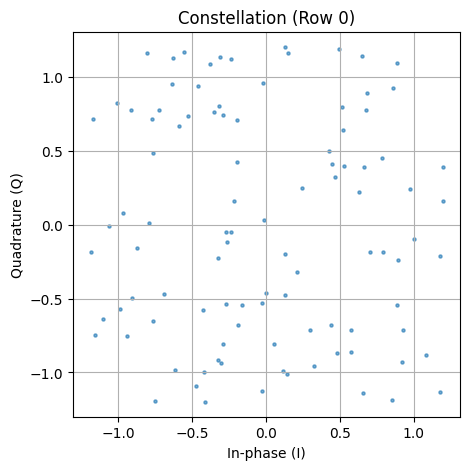

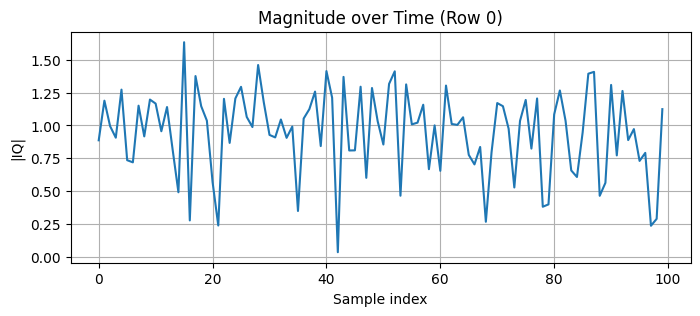

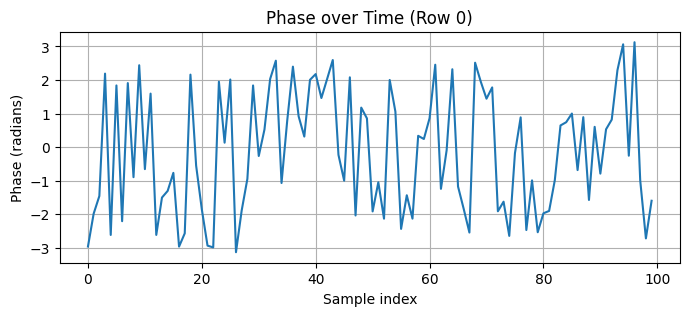

Band counts:
 Band
VHF    164160
Name: count, dtype: int64

Band percentages (%):
 Band
VHF    100.0
Name: count, dtype: float64


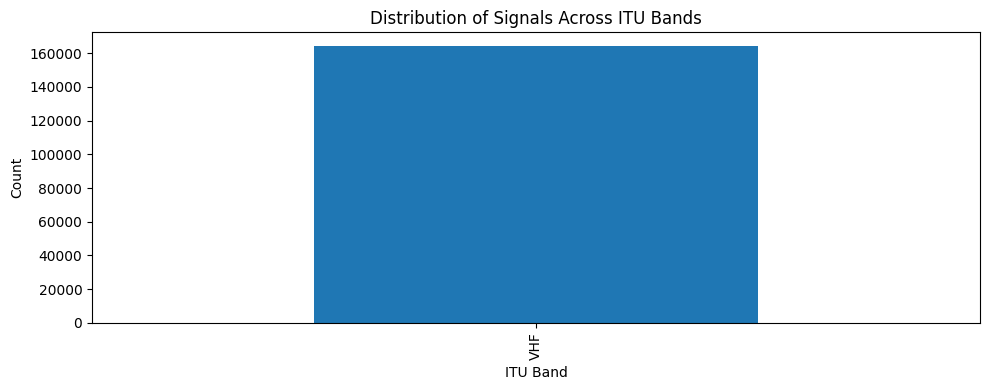


Band summary table:
   Band   Count  Percent                              ExampleUse
0  VHF  164160    100.0  FM, TV, aviation, land/mobile, weather
VHF sub-band counts:
 VHF_Subband
Airband_Comm    27285
FM_Broadcast    54577
Sat_137_144     27509
VHF_Other       54789
Name: count, dtype: int64

VHF sub-band %:
 VHF_Subband
Airband_Comm    16.62
FM_Broadcast    33.25
Sat_137_144     16.76
VHF_Other       33.38
Name: count, dtype: float64


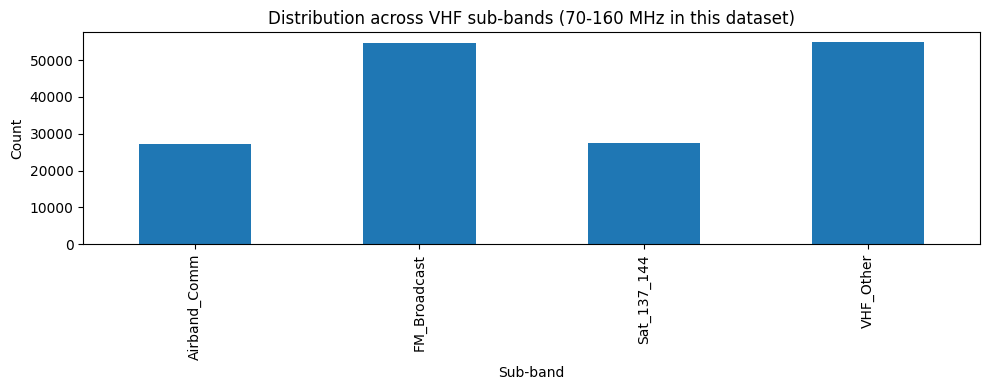

In [2]:
data_clean1 = data.drop(columns=[col for col in data.select_dtypes(include='object').columns if col != "I/Q Data"])
data_clean2 = data_clean1.drop(columns = ['Air Pressure'])
data_clean2["Frequency"] = pd.to_numeric(data_clean2["Frequency"], errors="coerce")

def parse_iq_cell(cell):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return np.array([], dtype=np.complex128)

    if isinstance(cell, str):
        s = cell.strip()
        try:
            obj = ast.literal_eval(s)
        except Exception:
            return np.array([], dtype=np.complex128)
        cell = obj
    if isinstance(cell, (list, tuple, np.ndarray)):
        return np.asarray(cell, dtype=np.complex128).ravel()
    try:
        return np.atleast_1d(np.complex128(cell))
    except Exception:
        return np.array([], dtype=np.complex128)

data_clean2["I/Q Data"] = data_clean2["I/Q Data"].apply(parse_iq_cell)

def fix_length(xc, target_len=100):
    xc = np.asarray(xc, dtype=np.complex128).ravel()
    n = xc.size
    if n >= target_len:
        return xc[:target_len]
    out = np.zeros(target_len, dtype=np.complex128)
    out[:n] = xc
    return out

def iq_normalize(xc, eps=1e-12):
    xc = np.asarray(xc, dtype=np.complex128).ravel()
    if xc.size == 0:
        return xc
    power = np.mean(np.abs(xc)**2) + eps
    return xc / np.sqrt(power)

TARGET_LEN = 100
data_clean2["iq_fixed"] = data_clean2["I/Q Data"].apply(lambda z: fix_length(z, TARGET_LEN))
data_clean2["iq_norm"]  = data_clean2["iq_fixed"].apply(iq_normalize)
data_clean2["iq_len_raw"] = data_clean2["I/Q Data"].apply(lambda a: len(a) if isinstance(a, (list, np.ndarray)) else 0)
data_clean2["has_iq"] = data_clean2["iq_len_raw"] > 0

example_idx = 0
iq_samples = data_clean2["iq_norm"].iloc[example_idx]
data_clean2["Frequency"] = pd.to_numeric(data_clean2["Frequency"], errors="coerce")

#Plotting IQ Data
plt.figure(figsize=(5,5))
plt.scatter(np.real(iq_samples), np.imag(iq_samples), s=5, alpha=0.6)
plt.title(f"Constellation (Row {example_idx})")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure(figsize=(8,3))
plt.plot(np.abs(iq_samples))
plt.title(f"Magnitude over Time (Row {example_idx})")
plt.xlabel("Sample index")
plt.ylabel("|IQ|")
plt.grid(True)
plt.show()

phase = np.angle(iq_samples)
plt.figure(figsize=(8,3))
plt.plot(phase)
plt.title(f"Phase over Time (Row {example_idx})")
plt.xlabel("Sample index")
plt.ylabel("Phase (radians)")
plt.grid(True)
plt.show()

ITU_BANDS = [
    ("ELF", 1, 3, 30),                              #Hz
    ("SLF", 2, 30, 300),                            #Hz
    ("ULF", 3, 300, 3000),                          #Hz
    ("VLF", 4, 3_000, 30_000),                      #3–30 kHz
    ("LF", 5, 30_000, 300_000),                     #30–300 kHz
    ("MF", 6, 300_000, 3_000_000),                  #300 kHz–3 MHz
    ("HF", 7, 3_000_000, 30_000_000),               #3–30 MHz
    ("VHF", 8, 30_000_000, 300_000_000),            #30–300 MHz
    ("UHF", 9, 300_000_000, 3_000_000_000),         #300 MHz–3 GHz
    ("SHF", 10, 3_000_000_000, 30_000_000_000),     #3–30 GHz
    ("EHF", 11, 30_000_000_000, 300_000_000_000),   #30–300 GHz
    ("THF", 12, 300_000_000_000, 3_000_000_000_000) #300–3000 GHz
]

VHF_SUBBANDS = [
    ("FM_Broadcast", 87.5e6, 108e6),
    ("Airband_Nav", 108e6, 118e6),
    ("Airband_Comm", 118e6, 137e6),
    ("Sat_137_144", 137e6, 144e6),
    ("Ham_2m", 144e6, 148e6),
    ("LandMobile_150_156", 150e6, 156e6),
    ("Marine_VHF", 156e6, 160e6),
]

def classify_itu_band(freq_hz: float) -> str:
    if pd.isna(freq_hz):
        return "Unknown"
    for name, num, lo, hi in ITU_BANDS:
        if lo <= freq_hz < hi:
            return name
    return "OutOfRange"

def classify_vhf_subband(freq_hz):
    if pd.isna(freq_hz) or not (30e6 <= freq_hz < 300e6):
        return "NonVHF_orMissing"
    for name, lo, hi in VHF_SUBBANDS:
        if lo <= freq_hz < hi:
            return name
    return "VHF_Other"

data_clean2["Bandwidth"] = pd.to_numeric(data_clean2.get("Bandwidth", np.nan), errors="coerce")
freq_hz = data_clean2["Frequency"]
bw_hz   = data_clean2["Bandwidth"]
center_for_class = freq_hz 
data_clean2["Band"] = center_for_class.apply(classify_itu_band)
band_counts = data_clean2["Band"].value_counts(dropna=False).sort_index()
band_percent = (band_counts / band_counts.sum() * 100).round(2)

print("Band counts:\n", band_counts)
print("\nBand percentages (%):\n", band_percent)

#ITU Band Distribution Plot
plt.figure(figsize=(10,4))
band_counts.plot(kind="bar")
plt.title("Distribution of Signals Across ITU Bands")
plt.xlabel("ITU Band")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

EXAMPLE_USES = {
    "ELF":"Submarine comms",
    "SLF":"Submarine comms",
    "ULF":"Submarine/mines comms",
    "VLF":"Navigation, time signals, submarine",
    "LF":"Navigation, longwave, RFID",
    "MF":"AM broadcast, avalanche beacons",
    "HF":"Shortwave, CB, amateur, OTH",
    "VHF":"FM, TV, aviation, land/mobile, weather",
    "UHF":"TV, microwave, mobile, Wi-Fi/Bluetooth, GPS",
    "SHF":"Microwave, WLAN, radar, satcom, DBS",
    "EHF":"mmWave, remote sensing, 802.11ad",
    "THF":"THz imaging/sensing/communications",
    "Unknown":"Missing freq",
    "OutOfRange":"Outside ITU table ranges"
}
band_summary = (
    pd.DataFrame({"Count": band_counts, "Percent": band_percent})
      .assign(ExampleUse=lambda d: d.index.map(EXAMPLE_USES).fillna(""))
      .reset_index(names="Band")
      .sort_values(["Count"], ascending=False)
)

print("\nBand summary table:\n", band_summary)

data_clean2["VHF_Subband"] = data_clean2["Frequency"].apply(classify_vhf_subband)

sub_counts = data_clean2["VHF_Subband"].value_counts().sort_index()
sub_pct = (sub_counts / sub_counts.sum() * 100).round(2)
print("VHF sub-band counts:\n", sub_counts)
print("\nVHF sub-band %:\n", sub_pct)

plt.figure(figsize=(10,4))
sub_counts.plot(kind="bar")
plt.title("Distribution across VHF sub-bands (70-160 MHz in this dataset)")
plt.ylabel("Count"); plt.xlabel("Sub-band"); plt.tight_layout(); plt.show()

Section 3: Creating Features

1. Starting out, row filtering rows that have I/Q data in them.
2. Set a lower limit of class counts at 200, then drop anything that doesn't have that. Given the size of the data I was trying to clean up as much as possible.
This could have been a potential limitation I didn't outline in my paper because I could have dropped something important.
3. On to the feature functions
    * iq_rich_features 
    * XC is my 1D complex array of my I/Q data, this is to b usable. This is also all together in one column rather than separate I and Q columns.
        * Time domain features
            * Statistics
                * amp.mean - average wave level
                * amp.std - wave variability
                * skew(amp) - wave asymmetry
                * kurtosis(amp) - peaks and trough weights basically. can track bursts and other impulsive waves
                    * (Kurtosis is a statistical measure of a probability distribution's tailedness and peakedness, indicating the
                    * extent of outliers and the distribution's overall shape - Googled) This is very important in RF signals since they are waves.
                * dphi.mean - signal phase change averages (dphi is a discrete derivative of the unwrapped phase, I Googled/AI'd these features)
                * dphi.std - variability, high FM-like, low for AM-like.
                * skew(dphi) - frequency swings
                * kurtosis(dphi) - jitters, spikes, and abrupt change sin the frequencies are higher kurtosis. Smooth is moderate
                * core(amp, dphi)
                * crest - peak to average ratio
            * Frequency Domain Features - Welch Power Spectral Density
                * PSD computation with Welch f, Pxx = welch()
                * This is used to estimate the spectral density of my complex array (XC)
                * Welch splits this into overlapping windows, and averages the periodograms.
                * fs - sampling rate
                * s = np.abs(Pxx) this is for non negative stability. PSD should be non negative.
                * Centroid - energy center mass
                * Spread - dispersion
                * Flatness - geometric mean/ arithmetic mean (near 1 for noise-like flat spectra; small for tonal/peaky spectra)
                * Entropy - spectral randomness
                * OBW - occupied bandwidth
                * n_peaks - count of strong peaks above mean 2*std - tone count
            * Bins
                * 32 bins across the PSD - dimensionality control
    * iq_raw_amp_features
        * Using my pre-normalized I/Q data with iq_fixed this retains pure amplitude before unit-power normalization.
        * AM vs FM differences show up in amplitude dynamics.

* So in essences the two features are based around shape/structure and raw amplitudes of the signals.




In [3]:
dfm = data_clean2.loc[data_clean2["has_iq"] & (data_clean2["VHF_Subband"] != "NonVHF_orMissing")].copy()

MIN_PER_CLASS = 200
vc = dfm["VHF_Subband"].value_counts()
keep_labels = vc[vc >= MIN_PER_CLASS].index.tolist()
dfm = dfm[dfm["VHF_Subband"].isin(keep_labels)].reset_index(drop=True)
print("Classes kept and counts:\n", dfm["VHF_Subband"].value_counts())

def iq_rich_features(xc, fs=1.0, nperseg=64, noverlap=32, target_bins=32):
    xc = np.asarray(xc, dtype=np.complex128).ravel()
    I = xc.real
    Q = xc.imag
    amp = np.abs(xc)
    ph  = np.unwrap(np.angle(xc))
    dphi = np.diff(ph, prepend=ph[0])

    def safe_skew(x):  return float(skew(x)) if np.std(x) > 0 else 0.0
    def safe_kurt(x):  return float(kurtosis(x)) if np.std(x) > 0 else 0.0
    def safe_corr(a,b): 
        return float(np.corrcoef(a,b)[0,1]) if (np.std(a)>0 and np.std(b)>0) else 0.0
    crest = (np.max(amp)+1e-12) / (np.mean(amp)+1e-12)
    td_feats = [
        amp.mean(), amp.std(ddof=1), safe_skew(amp), safe_kurt(amp),
        dphi.mean(), dphi.std(ddof=1), safe_skew(dphi), safe_kurt(dphi),
        safe_corr(amp, dphi), crest
    ]

    f, Pxx = welch(xc, fs=fs, nperseg=nperseg, noverlap=noverlap, return_onesided=False)
    S = np.abs(Pxx) + 1e-12
    Sn = S / S.sum()

    f_norm = np.linspace(-0.5, 0.5, len(S))
    centroid = float((f_norm * Sn).sum())
    spread   = float(np.sqrt(((f_norm - centroid)**2 * Sn).sum()))
    flatness = float(np.exp(np.log(S).mean()) / S.mean())
    entropy  = float(-(Sn * np.log(Sn)).sum())

    cdf = np.cumsum(Sn)
    lo_idx = int(np.searchsorted(cdf, 0.01))
    hi_idx = int(np.searchsorted(cdf, 0.99))
    obw = (hi_idx - lo_idx) / len(S)

    peaks, _ = find_peaks(S, height=(S.mean() + 2*S.std()))
    n_peaks = len(peaks)

    spec_desc = [centroid, spread, flatness, entropy, obw, n_peaks]

    idx = np.linspace(0, len(S)-1, target_bins).astype(int)
    spec_bins = np.log10(S[idx])

    return np.concatenate([td_feats, spec_desc, spec_bins])

def iq_raw_amp_features(x_raw):
    x_raw = np.asarray(x_raw, dtype=np.complex128).ravel()
    amp = np.abs(x_raw)
    return np.array([
        amp.mean(),                      
        amp.std(ddof=1),                 
        float(np.mean(amp**2)),          
        float(np.max(amp) - np.min(amp)) 
    ], dtype=float)


Classes kept and counts:
 VHF_Subband
VHF_Other       36532
FM_Broadcast    36290
Sat_137_144     18411
Airband_Comm    18091
Name: count, dtype: int64


Section 4: Feature Building


In [4]:
X_iq = np.vstack([iq_rich_features(x) for x in dfm["iq_norm"]])
X_raw = np.vstack([iq_raw_amp_features(x) for x in dfm["iq_fixed"]])
bw = pd.to_numeric(dfm["Bandwidth"], errors="coerce").fillna(0).to_numpy().reshape(-1,1)
ss = pd.to_numeric(dfm["Signal Strength"], errors="coerce").fillna(0).to_numpy().reshape(-1,1)
X = np.hstack([bw, ss, X_raw, X_iq])
scaler = StandardScaler()
X = scaler.fit_transform(X)


Section 5: K-Fold Validation & Training
1. multi and binary class lables with the label encoder, two stage pipeline, 1 is a binary effort, 2 is rows predicted Non-FM
2. Train/Test split
3. Outlining most useful columns for FM vs Non-FM and the PSD descriptors (gate_cols)
4. my 5 fold cross validation with stratifiedKfold - used stratified instead of regular to help with impalancing problems due to the data set being so large. Don't know if this was needed or not but I went with it
5. Random Forest
    * Used calibrated to handle the probability outputs by random forest. 
    


In [6]:
le = LabelEncoder()
y = le.fit_transform(dfm["VHF_Subband"])
y_fm = (dfm["VHF_Subband"] == "FM_Broadcast").astype(int).to_numpy()

Xtr, Xte, ytr_fm, yte_fm, ytr_mc, yte_mc = train_test_split(
    X, y_fm, y, test_size=0.2, stratify=y_fm, random_state=42
)
gate_cols = [0, 1, 2, 3, 4, 5, 16, 17, 18, 19, 20, 21]
Xtr_g, Xte_g = Xtr[:, gate_cols], Xte[:, gate_cols]

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
val_probs = []
val_labels = []
f1_scores = []
thresholds = []

fold_precisions = []
fold_recalls = []
fold_f1s = []

for fold, (train_idx, val_idx) in enumerate(skf.split(Xtr_g, ytr_fm)):
    X_tri, X_val = Xtr_g[train_idx], Xtr_g[val_idx]
    y_tri, y_val = ytr_fm[train_idx], ytr_fm[val_idx]

    rf_gate = RandomForestClassifier(n_estimators=600,min_samples_leaf=2,class_weight="balanced",max_features="sqrt",n_jobs=-1,random_state=42).fit(X_tri, y_tri)
    cal_gate = CalibratedClassifierCV(FrozenEstimator(rf_gate),method="isotonic").fit(X_val, y_val)
    
    val_prob = cal_gate.predict_proba(X_val)[:, 1]
    val_probs.extend(val_prob)
    val_labels.extend(y_val)
    prec, rec, thr = precision_recall_curve(y_val, val_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    f1_scores.append(f1[:-1])
    thresholds.append(thr)
    best_idx = np.nanargmax(f1[:-1]) if len(thr) else 0
    best_thr = thr[best_idx] if len(thr) else 0.5
    fold_pred = (val_prob >= best_thr).astype(int)
    fold_report = classification_report(y_val, fold_pred, output_dict=True)
    fold_precisions.append(fold_report["1"]["precision"])
    fold_recalls.append(fold_report["1"]["recall"])
    fold_f1s.append(fold_report["1"]["f1-score"])
print("\nCross-Validation Metrics (FM class, mean ± std):")
print(f"Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"Recall: {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"F1-Score: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f


Cross-Validation Metrics (FM class, mean ± std):
Precision: 0.3321 ± 0.0001
Recall: 0.9998 ± 0.0003
F1-Score: 0.4985 ± 0.0001


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Section 6 - Testing


Chosen FM_THRESH=0.250 | gate pos rate (pred) on test = 0.134

FM Gate report (tuned, calibrated, test set):
               precision    recall  f1-score   support

       NonFM     0.6690    0.8674    0.7554     14607
          FM     0.3380    0.1363    0.1942      7258

    accuracy                         0.6247     21865
   macro avg     0.5035    0.5018    0.4748     21865
weighted avg     0.5591    0.6247    0.5691     21865

Feature Bandwidth: 0.0392
Feature Signal Strength: 0.0871
Feature raw_amp_mean: 0.0971
Feature raw_amp_std: 0.1031
Feature raw_power: 0.0974
Feature raw_dynamic_range: 0.1052
Feature centroid: 0.1051
Feature spread: 0.1051
Feature flatness: 0.1024
Feature entropy: 0.1024
Feature obw: 0.0293
Feature n_peaks: 0.0266


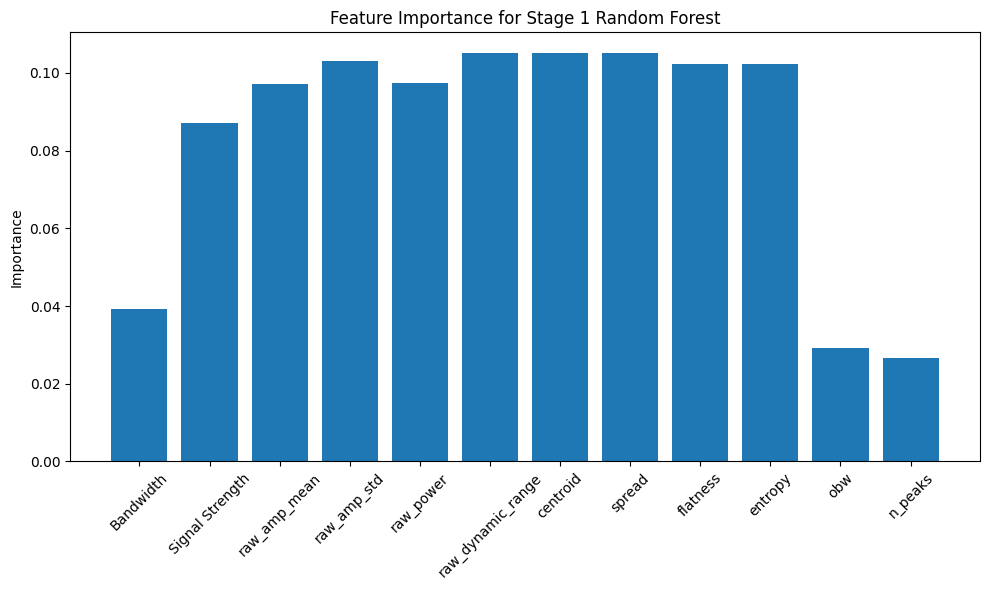

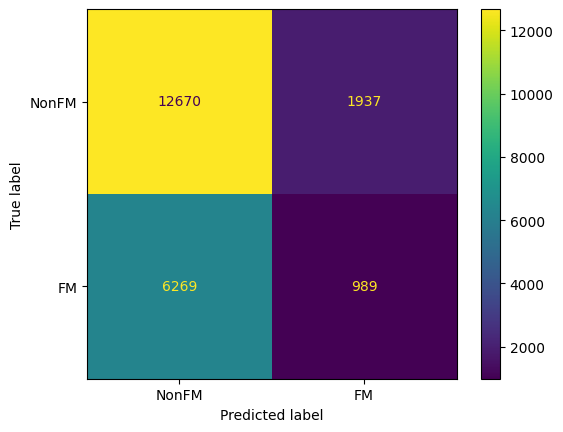

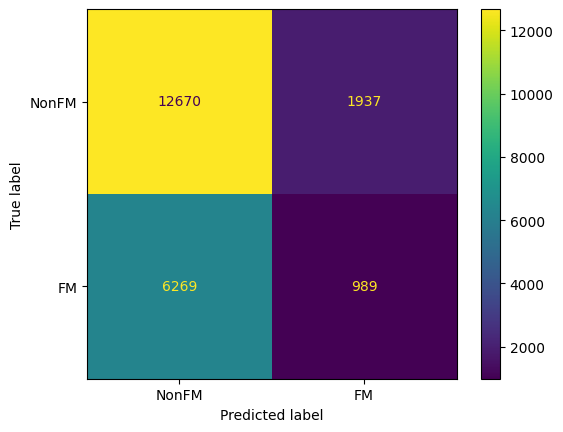

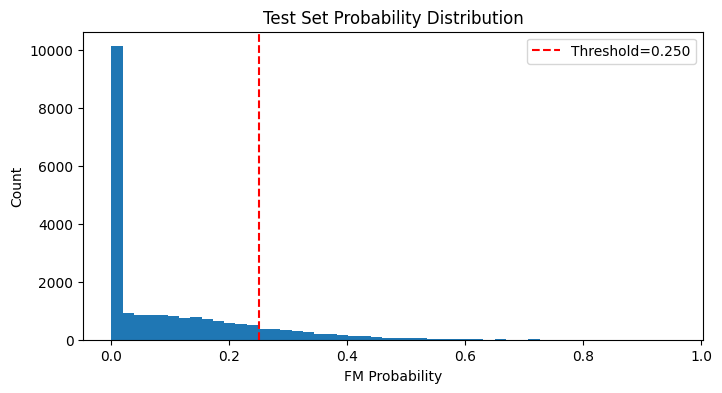

In [7]:

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)
prec, rec, thr = precision_recall_curve(val_labels, val_probs)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
idx = int(np.nanargmax(f1[:-1])) if len(thr) else 0
FM_THRESH = float(thr[idx]) if len(thr) else 0.5

rf_gate_final = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, class_weight="balanced", max_features="sqrt", n_jobs=-1, random_state=42).fit(Xtr_g, ytr_fm)
cal_gate_final = CalibratedClassifierCV(FrozenEstimator(rf_gate_final), method="isotonic", cv=5).fit(Xtr_g, ytr_fm)

fm_prob = cal_gate_final.predict_proba(Xte_g)[:, 1]
fm_pred = (fm_prob >= FM_THRESH).astype(int)

print(f"\nChosen FM_THRESH={FM_THRESH:.3f} | gate pos rate (pred) on test = {fm_pred.mean():.3f}")
print("\nFM Gate report (tuned, calibrated, test set):\n",
      classification_report(yte_fm, fm_pred, target_names=['NonFM', 'FM'], digits=4))


feature_names = ["Bandwidth", "Signal Strength", "raw_amp_mean", "raw_amp_std", "raw_power",
                 "raw_dynamic_range", "centroid", "spread", "flatness", "entropy", "obw", "n_peaks"]
importances = rf_gate_final.feature_importances_
for name, imp in zip(feature_names, importances):
    print(f"Feature {name}: {imp:.4f}")


plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance for Stage 1 Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()


ConfusionMatrixDisplay.from_predictions(yte_fm, fm_pred, display_labels=["NonFM", "FM"]).plot()
plt.savefig("confusion_matrix.png")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(fm_prob, bins=50)
plt.axvline(FM_THRESH, color="r", linestyle="--", label=f"Threshold={FM_THRESH:.3f}")
plt.title("Test Set Probability Distribution")
plt.xlabel("FM Probability")
plt.ylabel("Count")
plt.legend()
plt.savefig("probability_distribution.png")
plt.show()